# 03 · Evaluation

## 0 · Local Setup  *(run every session)*

In [224]:
from pathlib import Path
import sys, yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(f'Cannot find project root from {Path.cwd()}')

sys.path.insert(0, str(PROJECT_ROOT))

missing = []
for pkg in ['pretty_midi', 'yaml', 'sklearn']:
    try:
        __import__(pkg)
    except Exception:
        missing.append(pkg)
if missing:
    print(f'Missing packages: {missing}')
    print('Install with: pip install pretty_midi PyYAML scikit-learn')

with open(PROJECT_ROOT / 'configs' / 'base.yaml') as f:
    config = yaml.safe_load(f)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('Config loaded ✓')

PROJECT_ROOT = /root/autodl-tmp/music-style-transfer
Config loaded ✓


## 1 · Imports & Load Best Model

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from torch.utils.data import DataLoader

from src.models.ec2vae                  import EC2VAE
from src.data.dataset                   import MusicDataset
from src.evaluation.metrics             import (
    reconstruction_loss, evaluate_transfer_batch,
    rhythmic_density, rhythmic_entropy,
    pitch_class_histogram_divergence, save_metrics,
)
from src.evaluation.genre_classifier    import (
    train_genre_classifier, compute_fooling_rate,
    save_classifier, load_classifier,
)
from src.evaluation.visualize           import (
    plot_piano_roll_comparison, plot_tsne_latent_space,
    plot_pitch_class_histograms, plot_rhythm_comparison,
    plot_latent_interpolation,
)

DATA_DIR = Path(PROJECT_ROOT) / 'data' / 'processed'
CKPT_BASE = Path(os.environ.get('MST_CHECKPOINT_BASE', str(PROJECT_ROOT))).expanduser().resolve()
CKPT_DIR = CKPT_BASE / 'checkpoints'
FIG_DIR  = Path(PROJECT_ROOT) / 'outputs' / 'figures'
MET_DIR  = Path(PROJECT_ROOT) / 'outputs' / 'metrics'
GENRES   = ['jazz', 'pop']
FIG_DIR.mkdir(parents=True, exist_ok=True)
MET_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Checkpoint dir: {CKPT_DIR}')

model = EC2VAE.from_config(config).to(device)
ckpt_name = os.environ.get('MST_EVAL_CKPT', 'latest.pt')
ckpt_path = CKPT_DIR / ckpt_name
if not ckpt_path.exists():
    fallback = CKPT_DIR / 'best_model.pt'
    if fallback.exists():
        print(f'Missing {ckpt_name}, fallback to best_model.pt')
        ckpt_path = fallback
    else:
        raise FileNotFoundError(f'Missing checkpoint: {ckpt_path}')

ckpt  = torch.load(str(ckpt_path), map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded {ckpt_path.name}  (epoch={ckpt["epoch"]})')

Device: cuda
Checkpoint dir: /root/autodl-tmp/music-style-transfer/checkpoints
Loaded latest.pt  (epoch=67)


## 2 · DataLoaders (val + test)

In [ ]:
BATCH = config['training']['batch_size']

val_ds   = MusicDataset(str(DATA_DIR), GENRES, split='val')
test_ds  = MusicDataset(str(DATA_DIR), GENRES, split='test')
train_ds = MusicDataset(str(DATA_DIR), GENRES, split='train', augment=False)

val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=True,  num_workers=2)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)

print(f'val={len(val_ds)}  test={len(test_ds)}  train={len(train_ds)}')
print(f'train per genre: {train_ds.genre_counts()}')

val=20868  test=20871  train=166948
train per genre: {'jazz': 84120, 'pop': 82828}


---
## 3 · Reconstruction Loss (val set)

In [227]:
recon_metrics = reconstruction_loss(model, val_loader, device, config)

print('Reconstruction metrics (val set):')
for k, v in recon_metrics.items():
    print(f'  {k:<18}: {v:.4f}')

save_metrics(recon_metrics, str(MET_DIR / 'reconstruction_loss.json'))
print('Saved → outputs/metrics/reconstruction_loss.json')

Reconstruction metrics (val set):
  total             : 10.4886
  recon             : 0.1139
  kl                : 0.5890
  rhythm            : 17.2617
Saved → outputs/metrics/reconstruction_loss.json


---
## 4 · Transfer Metrics  (pitch KL + rhythm density/entropy)

In [ ]:
all_metrics = []

for i, (x, rhythm_gt, label) in enumerate(test_loader):
    if i >= 30:
        break
    B = x.size(0)
    if B < 2:
        continue

    x = x.to(device)
    label = label.to(device)

    content_idx = []
    style_idx = []

    for cont_i in range(B):
        candidates = (label != label[cont_i]).nonzero(as_tuple=False).flatten()
        if candidates.numel() == 0:
            continue
        style_i = candidates[torch.randint(candidates.numel(), (1,), device=label.device)].item()
        content_idx.append(cont_i)
        style_idx.append(style_i)

    if not content_idx:
        continue

    x_content = x[content_idx]
    x_style = x[style_idx]
    m = evaluate_transfer_batch(model, x_content, x_style, device)
    all_metrics.append(m)

avg_metrics = {}
for k in all_metrics[0].keys():
    avg_metrics[k] = float(np.mean([m[k] for m in all_metrics]))

print('Transfer metrics (cross-genre pairs, averaged over 30 batches):')
print(f"  Pitch KL divergence (↓ better)  : {avg_metrics['pitch_kl_div']:.4f}")
print(f"  Rhythm density — content source : {avg_metrics['rhythm_density_content']:.4f}")
print(f"  Rhythm density — style source   : {avg_metrics['rhythm_density_style']:.4f}")
print(f"  Rhythm density — transferred    : {avg_metrics['rhythm_density_transfer']:.4f}")
print(f"  Rhythm density distance (↓ better): {avg_metrics['rhythm_density_dist']:.4f}")
print(f"  Rhythm entropy — transferred    : {avg_metrics['rhythm_entropy_transfer']:.4f}")

save_metrics(avg_metrics, str(MET_DIR / 'transfer_metrics.json'))
print('\nSaved → outputs/metrics/transfer_metrics.json')

Transfer metrics (cross-genre pairs, averaged over 30 batches):
  Pitch KL divergence (↓ better)  : 3.2099
  Rhythm density — content source : 0.9817
  Rhythm density — style source   : 0.9821
  Rhythm density — transferred    : 0.9985
  Rhythm density distance (↓ better): 0.0184
  Rhythm entropy — transferred    : 0.0030

Saved → outputs/metrics/transfer_metrics.json


---
## 5 · Genre Classifier + Fooling Rate

In [ ]:
import importlib
import src.evaluation.genre_classifier as gc
importlib.reload(gc)

CLF_PATH = str(CKPT_DIR / 'genre_classifier.pt')
RETRAIN_CLASSIFIER = False 

if Path(CLF_PATH).exists() and not RETRAIN_CLASSIFIER:
    print('Loading existing genre classifier...')
    classifier = gc.load_classifier(
        CLF_PATH, device,
        n_classes=len(GENRES),
        input_dim=config['model']['input_dim'],
        seq_len=config['data']['seq_len'],
    )
else:
    print('Training genre classifier...')
    classifier = gc.train_genre_classifier(
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        n_classes=len(GENRES),
        epochs=30,
        lr=3e-4,
        weight_decay=1e-4,
        lr_patience=3,
        lr_factor=0.5,
        early_stop_patience=10,
        early_stop_min_delta=1e-3,
        input_dim=config['model']['input_dim'],
        seq_len=config['data']['seq_len'],
    )
    gc.save_classifier(classifier, CLF_PATH)
    print(f'Saved → {CLF_PATH}')

Loading existing genre classifier...


In [230]:
fooling_results = gc.compute_fooling_rate(
    classifier=classifier,
    ec2vae=model,
    loader=test_loader,
    genres=GENRES,
    device=device,
    n_batches=30,
    threshold=0.5,
    cross_genre_only=True,
    random_seed=42,
    n_repeats=5,
)

print('Genre Classifier Fooling Rate (cross-genre pairs):')
print(f"  Overall fooling rate  : {fooling_results['fooling_rate']:.3f}")
print(f"  Content accuracy      : {fooling_results['content_accuracy']:.3f}")
print(f"  Samples evaluated     : {fooling_results['n_samples']}")
print(f"  Cross-genre pairs     : {fooling_results.get('n_cross_genre_pairs', 'n/a')}")
print(f"  Same-genre pairs      : {fooling_results.get('n_same_genre_pairs', 'n/a')}")
print(f"  Random seed           : {fooling_results.get('random_seed', 'n/a')}")
print(f"  Repeats               : {fooling_results.get('n_repeats', 'n/a')}")
print('  Per-genre fooling rate:')
for genre, rate in fooling_results['per_genre'].items():
    print(f'    {genre:<12}: {rate:.3f}')

save_metrics(fooling_results, str(MET_DIR / 'fooling_rate.json'))
print('\nSaved → outputs/metrics/fooling_rate.json')

Genre Classifier Fooling Rate (cross-genre pairs):
  Overall fooling rate  : 0.588
  Content accuracy      : 0.412
  Samples evaluated     : 19200
  Cross-genre pairs     : 19200
  Same-genre pairs      : 0
  Random seed           : 42
  Repeats               : 5
  Per-genre fooling rate:
    jazz        : 0.670
    pop         : 0.508

Saved → outputs/metrics/fooling_rate.json


---
## 6 · Piano Roll Comparison (content / style / transferred)

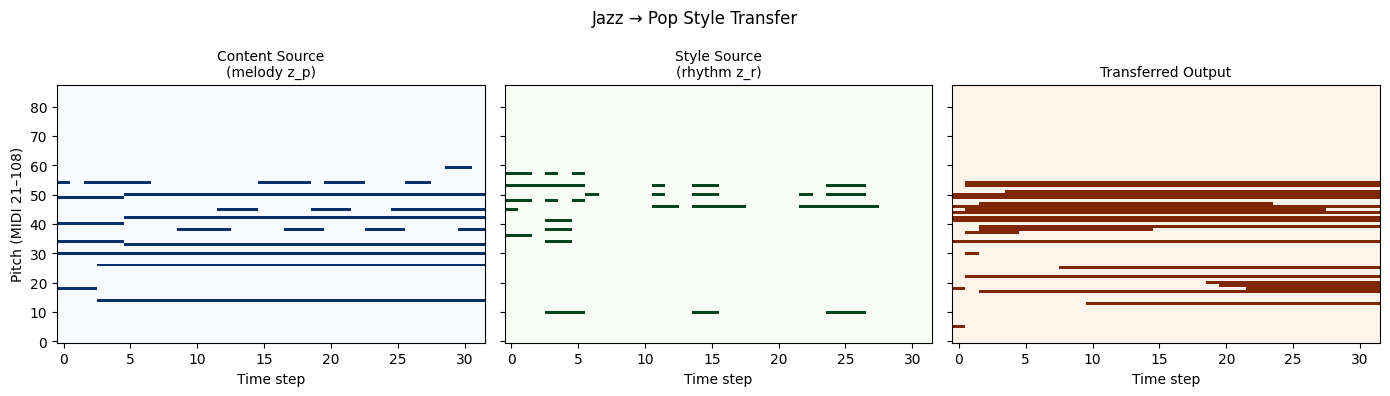

In [203]:
# Pick one cross-genre pair: jazz content → pop style
counts     = test_ds.genre_counts()
jazz_start = counts.get('classical', 0)
pop_start  = jazz_start + counts.get('jazz', 0)

x_content_np, _, _ = test_ds[jazz_start + 2]   # jazz sample
x_style_np,   _, _ = test_ds[pop_start  + 5]   # pop sample

x_c = x_content_np.unsqueeze(0).to(device)
x_s = x_style_np.unsqueeze(0).to(device)

with torch.no_grad():
    transferred = model.transfer(x_c, x_s).squeeze(0).cpu().numpy()

transferred_bin = (transferred > 0.5).astype(np.float32)

plot_piano_roll_comparison(
    roll_content=x_content_np.numpy(),
    roll_style=x_style_np.numpy(),
    roll_transferred=transferred_bin,
    title='Jazz → Pop Style Transfer',
    save_path=str(FIG_DIR / 'piano_roll_comparison.png'),
)

---
## 7 · Pitch Class Histogram Comparison

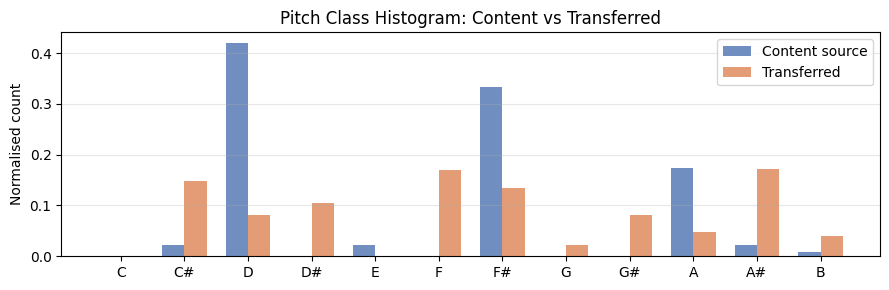

Pitch KL divergence (this sample): 3.9610  (lower = pitch content preserved)


In [204]:
plot_pitch_class_histograms(
    roll_content=x_content_np.numpy(),
    roll_transferred=transferred_bin,
    save_path=str(FIG_DIR / 'pitch_class_histograms.png'),
)

kl = pitch_class_histogram_divergence(x_content_np.numpy(), transferred_bin)
print(f'Pitch KL divergence (this sample): {kl:.4f}  (lower = pitch content preserved)')

---
## 8 · Rhythm Comparison

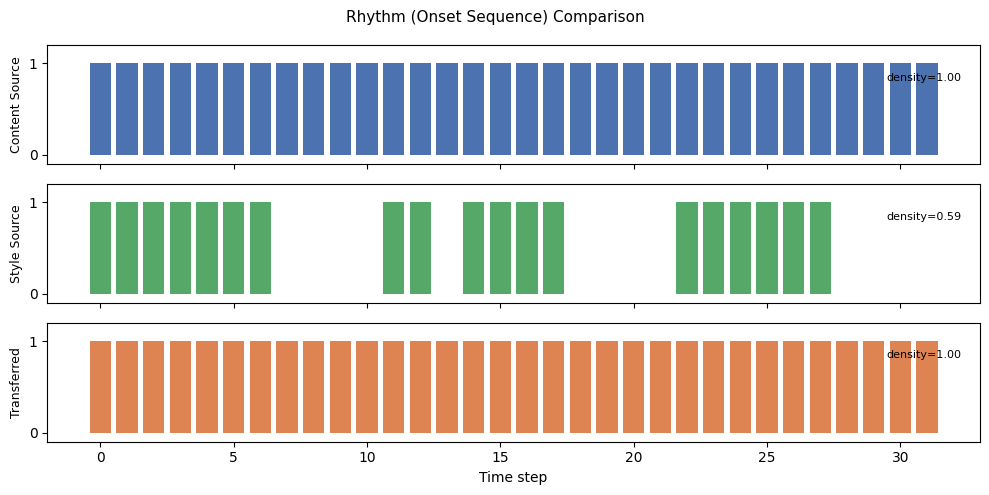

Rhythm density  — content    : 1.000
Rhythm density  — style      : 0.594
Rhythm density  — transferred: 1.000
Rhythm entropy  — transferred: -0.000


In [205]:
plot_rhythm_comparison(
    roll_content=x_content_np.numpy(),
    roll_style=x_style_np.numpy(),
    roll_transferred=transferred_bin,
    save_path=str(FIG_DIR / 'rhythm_comparison.png'),
)

print(f"Rhythm density  — content    : {rhythmic_density(x_content_np.numpy()):.3f}")
print(f"Rhythm density  — style      : {rhythmic_density(x_style_np.numpy()):.3f}")
print(f"Rhythm density  — transferred: {rhythmic_density(transferred_bin):.3f}")
print(f"Rhythm entropy  — transferred: {rhythmic_entropy(transferred_bin):.3f}")

---
## 9 · Optional: t-SNE Latent Space

This visualisation is **diagnostic only** and is not required for the main evaluation metrics.
You can skip it by keeping `ENABLE_TSNE = False`.

In [ ]:
ENABLE_TSNE = False  

if not ENABLE_TSNE:
    print('Skip t-SNE (optional diagnostic plot).')
else:
    import importlib
    import src.evaluation.visualize as viz
    importlib.reload(viz)

    try:
        import sklearn  # noqa: F401
    except Exception as e:
        print(f"Skip t-SNE: scikit-learn is not available ({e}).")
        print("Install with: pip install scikit-learn")
    else:
        viz.plot_tsne_latent_space(
            model=model,
            loader=test_loader,
            genres=GENRES,
            device=device,
            n_batches=40,
            save_path=str(FIG_DIR / 'tsne_latent_space.png'),
        )

Skip t-SNE (optional diagnostic plot).


---
## 10 · Evaluation Summary

In [231]:
all_results = {
    'reconstruction': recon_metrics,
    'transfer':       avg_metrics,
    'fooling':        fooling_results,
}
save_metrics(all_results, str(MET_DIR / 'full_eval_results.json'))

print('=' * 55)
print('Evaluation Summary')
print('=' * 55)
print(f"  Val recon loss        : {recon_metrics['recon']:.4f}")
print(f"  Val KL loss           : {recon_metrics['kl']:.4f}")
print(f"  Pitch KL divergence   : {avg_metrics['pitch_kl_div']:.4f}  (↓ pitch preserved)")
print(f"  Rhythm density dist   : {avg_metrics['rhythm_density_dist']:.4f}  (↓ style adopted)")
print(f"  Fooling rate          : {fooling_results['fooling_rate']:.3f}  (↑ style transfer)")
print('=' * 55)
print('\nAll metrics saved → outputs/metrics/')
print('All figures saved → outputs/figures/')
print('\n✓ Evaluation complete. Proceed to 04_demo.ipynb')

Evaluation Summary
  Val recon loss        : 0.1139
  Val KL loss           : 0.5890
  Pitch KL divergence   : 3.2099  (↓ pitch preserved)
  Rhythm density dist   : 0.0184  (↓ style adopted)
  Fooling rate          : 0.588  (↑ style transfer)

All metrics saved → outputs/metrics/
All figures saved → outputs/figures/

✓ Evaluation complete. Proceed to 04_demo.ipynb
